# AI600 - Assignment 2 - DL
**Roll No:** 25280081

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}  |  PyTorch {torch.__version__}')

Device: cpu  |  PyTorch 2.10.0+cpu


In [17]:
# data loading & normalization

train_npz = np.load('quickdraw_train.npz')
test_npz  = np.load('quickdraw_test.npz')

x_all       = train_npz['x_train'].astype(np.float32) / 255.0
y_all       = train_npz['y_train'].astype(np.int64)
class_names = [str(c) for c in train_npz['class_names']]
x_test_raw  = test_npz['test_images'].astype(np.float32) / 255.0

NUM_CLASSES = len(class_names)
INPUT_DIM   = 784

assert len(x_test_raw) == 15000
print(f'Train: {x_all.shape}  |  Test: {x_test_raw.shape}')
print(f'Classes ({NUM_CLASSES}): {class_names}')
print(f'Class distribution: {np.bincount(y_all)} (balanced: {np.bincount(y_all)[0]} per class)')


px_mean = x_all.mean(axis=0)
px_std  = x_all.std(axis=0) + 1e-8
x_norm      = (x_all      - px_mean) / px_std
x_test_norm = (x_test_raw - px_mean) / px_std

print(f'After z-score: mean={x_norm.mean():.4f}  std={x_norm.std():.4f}')

# 90/10 split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
tr_idx, va_idx = next(sss.split(x_norm, y_all))

x_tr_np, y_tr_np = x_norm[tr_idx], y_all[tr_idx]
x_va_np, y_va_np = x_norm[va_idx], y_all[va_idx]

x_train = torch.tensor(x_tr_np);  y_train = torch.tensor(y_tr_np)
x_val   = torch.tensor(x_va_np);  y_val   = torch.tensor(y_va_np)
x_test  = torch.tensor(x_test_norm)
x_full  = torch.tensor(x_norm);   y_full  = torch.tensor(y_all)

print(f'\nMonitoring split: Train={len(x_train):,}  Val={len(x_val):,}')
print(f'Final training  : Full={len(x_full):,}  Test={len(x_test):,}')

# batch size
BATCH = 256
train_ld = DataLoader(TensorDataset(x_train, y_train),
                      batch_size=BATCH, shuffle=True, drop_last=True,
                      num_workers=0, pin_memory=(DEVICE=='cuda'))
val_ld   = DataLoader(TensorDataset(x_val, y_val),
                      batch_size=512, shuffle=False)
full_ld  = DataLoader(TensorDataset(x_full, y_full),
                      batch_size=BATCH, shuffle=True, drop_last=True,
                      num_workers=0, pin_memory=(DEVICE=='cuda'))

print(f'Batch={BATCH}  |  steps/epoch: train={len(train_ld)}  full={len(full_ld)}')

Train: (60000, 784)  |  Test: (15000, 784)
Classes (15): ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']
Class distribution: [4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000
 4000] (balanced: 4000 per class)
After z-score: mean=-0.0000  std=0.9286

Monitoring split: Train=54,000  Val=6,000
Final training  : Full=60,000  Test=15,000
Batch=256  |  steps/epoch: train=210  full=234


In [18]:
# augmentation simulate all situtations
# scale + rotation + translation


def augment_batch(
    x: torch.Tensor,
    p_flip: float        = 0.50,
    max_rot_deg: float   = 18.0,
    max_shift: float     = 0.12,
    scale_range: float   = 0.20,
    cutout_size: int     = 8,
    noise_std: float     = 0.020,
) -> torch.Tensor:

    B, device = x.size(0), x.device
    imgs = x.view(B, 1, 28, 28)

    # pixel noise
    imgs = imgs + torch.randn_like(imgs) * noise_std

    # horizontal flip
    flip = torch.rand(B, device=device) < p_flip
    imgs = torch.where(flip.view(B,1,1,1).expand_as(imgs),
                       imgs.flip(dims=[-1]), imgs)

    # scale + Rotation + Translation

    angle = (torch.rand(B, device=device)*2 - 1) * max_rot_deg * (np.pi/180)
    scale = 1.0 + (torch.rand(B, device=device)*2 - 1) * scale_range  # [1-s, 1+s]
    tx    = (torch.rand(B, device=device)*2 - 1) * max_shift
    ty    = (torch.rand(B, device=device)*2 - 1) * max_shift

    cos_a = angle.cos() * scale
    sin_a = angle.sin() * scale
    theta = torch.zeros(B, 2, 3, device=device)
    theta[:, 0, 0] =  cos_a;  theta[:, 0, 1] = -sin_a;  theta[:, 0, 2] = tx
    theta[:, 1, 0] =  sin_a;  theta[:, 1, 1] =  cos_a;  theta[:, 1, 2] = ty

    grid = F.affine_grid(theta, imgs.size(), align_corners=False)
    imgs = F.grid_sample(imgs, grid, mode='bilinear',
                         padding_mode='zeros', align_corners=False)

    # cutout

    half = cutout_size // 2
    cx   = torch.randint(half+1, 28-half-1, (B,), device=device)
    cy   = torch.randint(half+1, 28-half-1, (B,), device=device)
    col  = torch.arange(28, device=device).view(1,28).expand(B,28)
    row  = torch.arange(28, device=device).view(1,28).expand(B,28)
    in_c = (col >= cx.unsqueeze(1)-half) & (col < cx.unsqueeze(1)+half)
    in_r = (row >= cy.unsqueeze(1)-half) & (row < cy.unsqueeze(1)+half)
    mask = (in_c.unsqueeze(2) & in_r.unsqueeze(1)).unsqueeze(1).float()
    imgs = imgs * (1.0 - mask)

    return imgs.view(B, 784)


print('Augmentation ')
print('  scale jitter: +/-20%  ')
print('  rotation    : +/-18 deg  ')
print('  flip        : 50%  ')
print('  cutout      : 8x8  ')

Augmentation 
  scale jitter: +/-20%  
  rotation    : +/-18 deg  
  flip        : 50%  
  cutout      : 8x8  


In [19]:
# Utilitiess

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def predict_single(model: nn.Module, x: torch.Tensor) -> np.ndarray:
    model.eval(); model.to(DEVICE)
    out = []
    for (xb,) in DataLoader(TensorDataset(x), batch_size=512, shuffle=False):
        out.append(model(xb.to(DEVICE)).argmax(1).cpu())
    return torch.cat(out).numpy()


@torch.no_grad()
def predict_tta(model: nn.Module, x: torch.Tensor) -> np.ndarray:

    model.eval(); model.to(DEVICE)

    def affine(xb, deg=0.0, sc=1.0, flip_first=False):
        B, dev = xb.size(0), xb.device
        if flip_first:
            xb = xb.view(B,1,28,28).flip(dims=[-1]).view(B,784)
        a = torch.tensor(deg*np.pi/180, device=dev)
        c, s = a.cos()*sc, a.sin()*sc
        theta = torch.zeros(B, 2, 3, device=dev)
        theta[:, 0, 0] = c;  theta[:, 0, 1] = -s
        theta[:, 1, 0] = s;  theta[:, 1, 1] =  c
        imgs = xb.view(B, 1, 28, 28)
        grid = F.affine_grid(theta, imgs.size(), align_corners=False)
        return F.grid_sample(imgs, grid, mode='bilinear',
                             padding_mode='zeros', align_corners=False).view(B,784)

    all_preds = []
    for (xb,) in DataLoader(TensorDataset(x), batch_size=512, shuffle=False):
        xb = xb.to(DEVICE)
        avg = (
            model(xb)                      +
            model(affine(xb, flip_first=True)) +
            model(affine(xb,  6.0))        +
            model(affine(xb, -6.0))        +
            model(affine(xb, 12.0))        +
            model(affine(xb,-12.0))        +
            model(affine(xb, 18.0))        +
            model(affine(xb,-18.0))        +
            model(affine(xb,  5.0, flip_first=True)) +
            model(affine(xb, -5.0, flip_first=True)) +
            model(affine(xb, 10.0, flip_first=True)) +
            model(affine(xb,-10.0, flip_first=True)) +
            model(affine(xb, 15.0, flip_first=True)) +
            model(affine(xb, sc=0.85))     +
            model(affine(xb, sc=1.15))
        ) / 15.0
        all_preds.append(avg.argmax(1).cpu())
    return torch.cat(all_preds).numpy()


def plot_curves(hist: dict, title: str) -> None:
    eps  = range(1, len(hist['tl'])+1)
    bv   = max(hist['va'])*100
    gap  = (hist['ta'][-1]-hist['va'][-1])*100
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(eps, hist['tl'], label='Train')
    ax1.plot(eps, hist['vl'], linestyle='--', label='Val')
    ax1.set(title=f'{title} — Loss', xlabel='Epoch', ylabel='Loss')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(eps, [a*100 for a in hist['ta']], label='Train')
    ax2.plot(eps, [a*100 for a in hist['va']], linestyle='--', label='Val')
    ax2.set(title=f'{title}\nBest Val={bv:.1f}%  Gap={gap:+.1f}%',
            xlabel='Epoch', ylabel='Accuracy (%)', ylim=[20,100])
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_").replace("—","").strip("_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


print('Utilities ready.')

Utilities ready.


In [20]:
# training loop

def train_model(
    model: nn.Module,
    tr_ld: DataLoader,
    va_ld: DataLoader,
    epochs: int         = 30,
    max_lr: float       = 2e-3,
    weight_decay: float = 3e-4,
    label_smooth: float = 0.10,
    mixup_alpha: float  = 0.30,
    use_augment: bool   = True,
    patience: int       = 20,
) -> tuple:

    model = model.to(DEVICE)
    train_crit = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    val_crit   = nn.CrossEntropyLoss()

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=max_lr, weight_decay=weight_decay, betas=(0.9, 0.999)
    )
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=max_lr,
        total_steps=epochs * len(tr_ld),
        pct_start=0.15, anneal_strategy='cos',
        div_factor=25.0, final_div_factor=1000.0
    )

    hist = {'tl': [], 'ta': [], 'vl': [], 'va': []}
    best_va = 0.0;  best_state = None;  best_ep = 0;  no_imp = 0

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0.0;  clean_ok = 0;  n = 0

        for xb, yb in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            xb_aug = augment_batch(xb) if use_augment else xb

            # Mixup without max(lam,1-lam) clamp

            if mixup_alpha > 0:
                lam = float(np.random.beta(mixup_alpha, mixup_alpha))
                idx = torch.randperm(xb_aug.size(0), device=DEVICE)
                xmix = lam * xb_aug + (1-lam) * xb_aug[idx]
                out  = model(xmix)
                loss = lam*train_crit(out, yb) + (1-lam)*train_crit(out, yb[idx])
            else:
                out  = model(xb_aug)
                loss = train_crit(out, yb)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()

            with torch.no_grad():
                clean_ok += (model(xb).argmax(1) == yb).sum().item()
            total_loss += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total_loss/n
        train_acc  = clean_ok/n

        model.eval()
        vls, vok, vn = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in va_ld:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                vls += val_crit(out, yb).item() * xb.size(0)
                vok += (out.argmax(1) == yb).sum().item()
                vn  += xb.size(0)
        val_loss = vls/vn
        val_acc  = vok/vn

        hist['tl'].append(train_loss); hist['ta'].append(train_acc)
        hist['vl'].append(val_loss);   hist['va'].append(val_acc)

        tag = ''
        if val_acc > best_va:
            best_va=val_acc; best_state=copy.deepcopy(model.state_dict())
            best_ep=ep; no_imp=0; tag=' .'
        else:
            no_imp += 1

        if ep % 5 == 0 or ep == 1 or tag:
            lr = opt.param_groups[0]['lr']
            print(f'  Ep {ep:2d}/{epochs}  '
                  f'train {train_acc*100:6.2f}%  '
                  f'val {val_acc*100:6.2f}%  '
                  f'gap {(train_acc-val_acc)*100:+.1f}%  '
                  f'lr={lr:.2e}{tag}')

        if no_imp >= patience:
            print(f'  Early stop at epoch {ep}')
            break

    model.load_state_dict(best_state)
    return hist, best_va, best_ep


print('Training loop ready.')

Training loop ready.


## Part A: Pancake Model

Pancake | 784->1024->1024->15 | 1,872,911 params 

Training Pancake Model
  Ep  1/25  train  54.86%  val  65.28%  gap -10.4%  lr=3.98e-04 .
  Ep  2/25  train  66.40%  val  67.48%  gap -1.1%  lr=1.14e-03 .
  Ep  3/25  train  69.23%  val  69.20%  gap +0.0%  lr=1.82e-03 .
  Ep  4/25  train  71.69%  val  72.98%  gap -1.3%  lr=2.00e-03 .
  Ep  5/25  train  73.68%  val  74.55%  gap -0.9%  lr=1.98e-03 .
  Ep  6/25  train  75.15%  val  75.95%  gap -0.8%  lr=1.94e-03 .
  Ep  7/25  train  76.07%  val  77.10%  gap -1.0%  lr=1.89e-03 .
  Ep  8/25  train  77.18%  val  77.73%  gap -0.6%  lr=1.81e-03 .
  Ep  9/25  train  77.87%  val  78.03%  gap -0.2%  lr=1.71e-03 .
  Ep 10/25  train  78.42%  val  78.85%  gap -0.4%  lr=1.60e-03 .
  Ep 11/25  train  79.06%  val  79.67%  gap -0.6%  lr=1.48e-03 .
  Ep 12/25  train  79.74%  val  80.52%  gap -0.8%  lr=1.34e-03 .
  Ep 13/25  train  80.08%  val  80.83%  gap -0.8%  lr=1.20e-03 .
  Ep 14/25  train  80.48%  val  81.58%  gap -1.1%  lr=1.05e-03 .
  Ep 15/25  tra

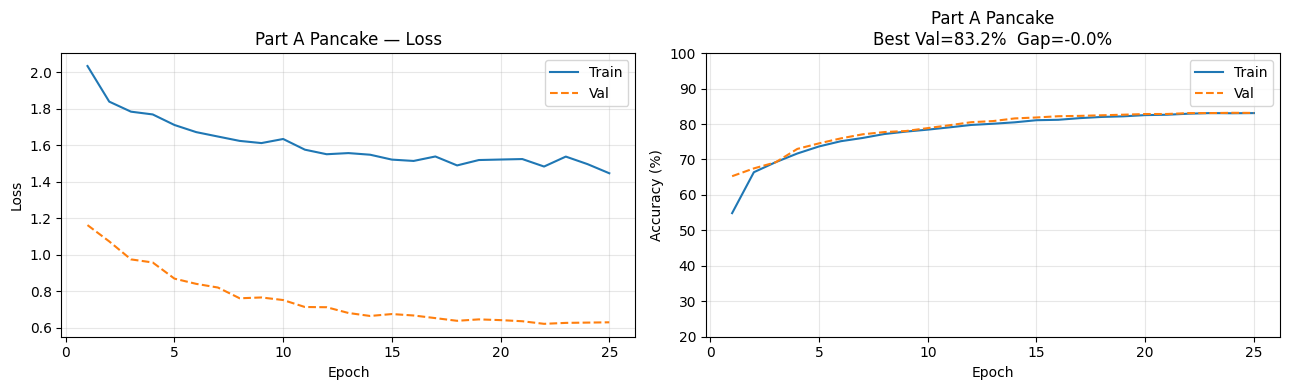

In [21]:
# part A - Pancake Model

class PancakeMLP(nn.Module):
    def __init__(self, input_dim=784, num_classes=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(1024, 1024),      nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(1024, num_classes)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x.view(-1, 784))


pancake   = PancakeMLP()
pancake_p = count_params(pancake)
assert pancake_p < 3_000_000, f'VIOLATION: {pancake_p:,}'
print(f'Pancake | 784->1024->1024->15 | {pancake_p:,} params ')

print('\nTraining Pancake Model')
pancake_h, pancake_bv, _ = train_model(
    pancake, train_ld, val_ld,
    epochs=25, max_lr=2e-3, weight_decay=3e-4,
    label_smooth=0.10, mixup_alpha=0.30, patience=15
)
print(f'\nPancake best val: {pancake_bv*100:.2f}%')
plot_curves(pancake_h, 'Part A Pancake')

## Part B: Tower Model

Tower | 784->[256x7]->15 | 603,151 params

Training Tower Model
  Ep  1/25  train  35.92%  val  59.08%  gap -23.2%  lr=2.99e-04 .
  Ep  2/25  train  61.50%  val  65.35%  gap -3.8%  lr=8.57e-04 .
  Ep  3/25  train  64.87%  val  67.17%  gap -2.3%  lr=1.36e-03 .
  Ep  4/25  train  67.70%  val  69.82%  gap -2.1%  lr=1.50e-03 .
  Ep  5/25  train  69.61%  val  71.63%  gap -2.0%  lr=1.49e-03 .
  Ep  6/25  train  70.94%  val  72.90%  gap -2.0%  lr=1.46e-03 .
  Ep  7/25  train  71.97%  val  73.15%  gap -1.2%  lr=1.41e-03 .
  Ep  8/25  train  72.74%  val  74.97%  gap -2.2%  lr=1.36e-03 .
  Ep  9/25  train  73.31%  val  75.15%  gap -1.8%  lr=1.28e-03 .
  Ep 10/25  train  73.95%  val  75.60%  gap -1.7%  lr=1.20e-03 .
  Ep 11/25  train  74.61%  val  76.33%  gap -1.7%  lr=1.11e-03 .
  Ep 12/25  train  75.19%  val  77.23%  gap -2.0%  lr=1.01e-03 .
  Ep 15/25  train  76.44%  val  78.20%  gap -1.8%  lr=6.80e-04 .
  Ep 16/25  train  76.82%  val  78.38%  gap -1.6%  lr=5.71e-04 .
  Ep 17/25  train  77.21%

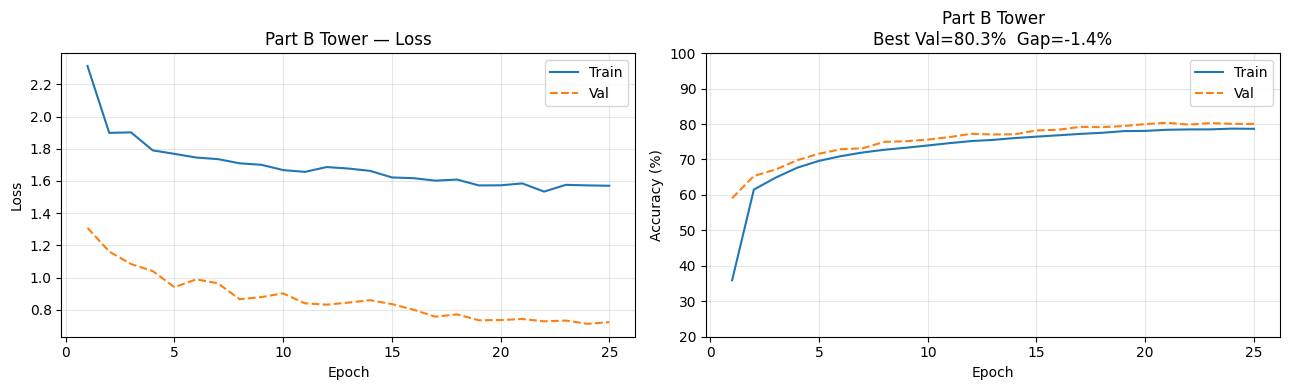

In [22]:
# part B - Tower Model

class TowerMLP(nn.Module):
    def __init__(self, input_dim=784, hidden=256, depth=7, num_classes=15):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden),
                  nn.GELU(), nn.Dropout(0.15)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden),
                       nn.GELU(), nn.Dropout(0.10)]
        layers.append(nn.Linear(hidden, num_classes))
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x.view(-1, 784))


tower   = TowerMLP(hidden=256, depth=7)
tower_p = count_params(tower)
assert tower_p < 3_000_000, f'VIOLATION: {tower_p:,}'
print(f'Tower | 784->[256x7]->15 | {tower_p:,} params')

print('\nTraining Tower Model')
tower_h, tower_bv, _ = train_model(
    tower, train_ld, val_ld,
    epochs=25, max_lr=1.5e-3, weight_decay=3e-4,
    label_smooth=0.10, mixup_alpha=0.30, patience=15
)
print(f'\nTower best val: {tower_bv*100:.2f}%')
plot_curves(tower_h, 'Part B Tower')

## Part C: Champion Model

In [23]:
# part C - Champion Model


class ChampionMLP(nn.Module):
    def __init__(self, input_dim=784, num_classes=15):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 384), nn.BatchNorm1d(384), nn.GELU(), nn.Dropout(0.35),

            # Layer 2
            nn.Linear(384, 256),       nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.25),

            # Layer 3
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.15),

            # Output
            nn.Linear(128, num_classes)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x): return self.net(x.view(-1, 784))


champion   = ChampionMLP()
champion_p = count_params(champion)

expected_p = (
    (784*384+384)+(2*384) +
    (384*256+256)+(2*256) +
    (256*128+128)+(2*128) +
    (128*15+15)
)
assert champion_p == expected_p, f'Param mismatch: {champion_p} vs {expected_p}'
assert champion_p < 3_000_000,   f'VIOLATION: {champion_p:,}'

print(f'Champion | 784->384->256->128->15')
print(f'Params   : {champion_p:,} ')



Champion | 784->384->256->128->15
Params   : 436,367 


Champion monitoring run (90/10 split)
  Architecture : 784->384->256->128->15 (436,367 params)
  Dropout      : 0.35->0.25->0.15  
  Weight decay : 3e-4  
  Mixup alpha  : 0.30  
  Scale jitter : +/-20%  
  Cutout       : 8x8  

  Ep  1/30  train  39.72%  val  56.15%  gap -16.4%  lr=3.05e-04 .
  Ep  2/30  train  60.19%  val  66.32%  gap -6.1%  lr=8.75e-04 .
  Ep  3/30  train  64.75%  val  68.12%  gap -3.4%  lr=1.52e-03 .
  Ep  4/30  train  67.01%  val  70.38%  gap -3.4%  lr=1.94e-03 .
  Ep  5/30  train  68.85%  val  71.08%  gap -2.2%  lr=2.00e-03 .
  Ep  6/30  train  70.35%  val  73.22%  gap -2.9%  lr=1.98e-03 .
  Ep  7/30  train  71.32%  val  73.87%  gap -2.5%  lr=1.95e-03 .
  Ep  8/30  train  72.02%  val  74.47%  gap -2.4%  lr=1.91e-03 .
  Ep  9/30  train  72.74%  val  75.72%  gap -3.0%  lr=1.85e-03 .
  Ep 10/30  train  73.51%  val  76.32%  gap -2.8%  lr=1.78e-03 .
  Ep 12/30  train  74.49%  val  76.47%  gap -2.0%  lr=1.60e-03 .
  Ep 13/30  train  75.02%  val  77.88%  gap -2.9%  lr=1

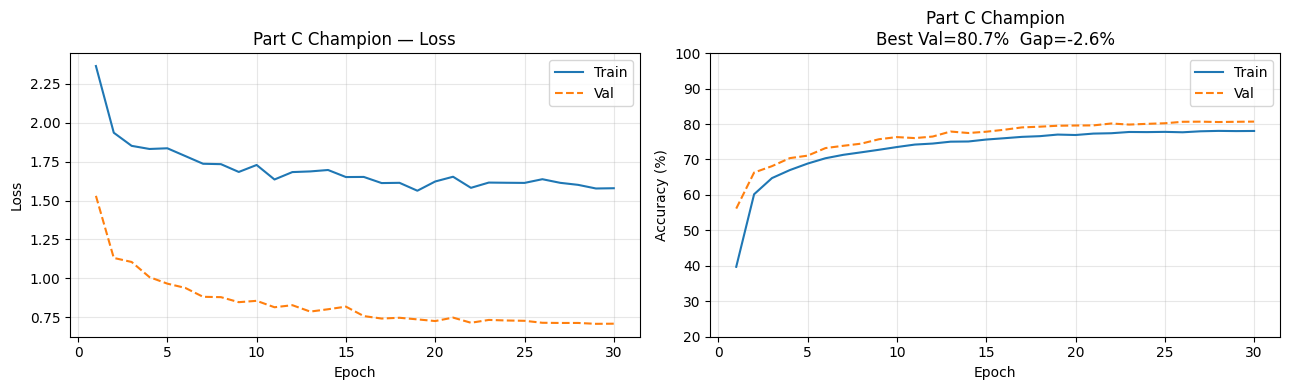

In [24]:
# Championn run (90/10 split)


print('Champion monitoring run (90/10 split)')
print(f'  Architecture : 784->384->256->128->15 ({champion_p:,} params)')
print(f'  Dropout      : 0.35->0.25->0.15  ')
print(f'  Weight decay : 3e-4  ')
print(f'  Mixup alpha  : 0.30  ')
print(f'  Scale jitter : +/-20%  ')
print(f'  Cutout       : 8x8  ')
print()

t0 = time.time()
champ_h, champ_bv, best_ep = train_model(
    champion, train_ld, val_ld,
    epochs=30,
    max_lr=2e-3,
    weight_decay=3e-4,
    label_smooth=0.10,
    mixup_alpha=0.30,
    use_augment=True,
    patience=20
)

print(f'\nMonitoring run done in {(time.time()-t0)/60:.1f} min')
print(f'Best val accuracy : {champ_bv*100:.2f}%  at epoch {best_ep}')
print()


plot_curves(champ_h, 'Part C Champion')

In [25]:
# champion model trained on all 60,000 samplles

FINAL_EPOCHS = 25
print(f'Final Champion on 60k samples for {FINAL_EPOCHS} epochs')

champion_final = ChampionMLP().to(DEVICE)

final_crit = nn.CrossEntropyLoss(label_smoothing=0.10)
final_opt  = torch.optim.AdamW(
    champion_final.parameters(),
    lr=2e-3, weight_decay=3e-4, betas=(0.9, 0.999)
)
final_sched = torch.optim.lr_scheduler.OneCycleLR(
    final_opt, max_lr=2e-3,
    total_steps=FINAL_EPOCHS * len(full_ld),
    pct_start=0.15, anneal_strategy='cos',
    div_factor=25.0, final_div_factor=1000.0
)

t0 = time.time()
for ep in range(1, FINAL_EPOCHS + 1):
    champion_final.train()
    ok = 0;  n = 0

    for xb, yb in full_ld:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        xb_aug = augment_batch(xb)

        lam = float(np.random.beta(0.30, 0.30))
        idx = torch.randperm(xb_aug.size(0), device=DEVICE)
        xmix = lam * xb_aug + (1-lam) * xb_aug[idx]
        out  = champion_final(xmix)
        loss = lam*final_crit(out,yb) + (1-lam)*final_crit(out,yb[idx])

        final_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(champion_final.parameters(), 1.0)
        final_opt.step()
        final_sched.step()

        with torch.no_grad():
            ok += (champion_final(xb).argmax(1) == yb).sum().item()
        n += xb.size(0)

    if ep % 5 == 0 or ep == FINAL_EPOCHS:
        print(f'  Ep {ep:2d}/{FINAL_EPOCHS}  train {ok/n*100:.2f}%  ')


print(f'\nFinal training: {(time.time()-t0)/60:.1f} min')
print(f'Parameters: {champion_p:,}  |  Epochs: {FINAL_EPOCHS}')

Final Champion on 60k samples for 25 epochs
  Ep  5/25  train 69.76%  
  Ep 10/25  train 74.07%  
  Ep 15/25  train 76.38%  
  Ep 20/25  train 77.65%  
  Ep 25/25  train 78.01%  

Final training: 4.8 min
Parameters: 436,367  |  Epochs: 25


In [26]:
torch.save(champion_final.state_dict(), 'champion_weights.pt')

reload = ChampionMLP()
reload.load_state_dict(torch.load('champion_weights.pt', map_location='cpu'))
reload.eval()
with torch.no_grad():
    out = reload(torch.randn(4, 784))
assert out.shape == (4, 15)
del reload
print('Saved: champion_weights.pt ')

Saved: champion_weights.pt 


In [27]:
# generating predictiions

predictions = predict_tta(champion_final, x_test)


assert len(predictions) == 15000
assert int(predictions.min()) >= 0
assert int(predictions.max()) <= 14

print(f'Count: {len(predictions):,}  Range: [{predictions.min()},{predictions.max()}]  ')
print(f'Class distribution: {np.bincount(predictions, minlength=15)}')

single_preds = predict_single(champion_final, x_test)
changed = int((predictions != single_preds).sum())
print(f'TTA changed {changed:,} of 15,000 predictions vs single-pass')


submission = ','.join(map(str, predictions))
with open('test_set_pred_leaderboard.csv', 'w') as f:
    f.write(submission)

# Read-back check
with open('test_set_pred_leaderboard.csv') as f:
    rb = [int(v) for v in f.read().strip().split(',')]
assert rb == list(predictions), 'Read-back failed — do NOT submit'

print(f'\nSaved: test_set_pred_leaderboard.csv')
print(f'Preview: {submission[:72]}...')

print(f'  Parameters : {champion_p:,}')
print(f'  Epochs     : {FINAL_EPOCHS}')

Count: 15,000  Range: [0,14]  
Class distribution: [1048 1029  690 1037  870  844 1023  946 1001 1245 1090 1117 1073  985
 1002]
TTA changed 676 of 15,000 predictions vs single-pass

Saved: test_set_pred_leaderboard.csv
Preview: 6,11,5,5,0,1,11,9,14,8,9,7,11,11,13,8,13,12,11,3,13,6,14,8,0,13,13,2,6,5...
  Parameters : 436,367
  Epochs     : 25


## Part D : Theoretical Analysis

In [28]:
# part D

print()
print(f'  {"Model":<10}  {"Architecture":<26}  {"Params":>10}  {"Best Val":>9}')
print('  '+'-'*62)
print(f'  {"Pancake":<10}  {"784->1024->1024->15":<26}  {pancake_p:>10,}  {pancake_bv*100:>8.2f}%')
print(f'  {"Tower":<10}  {"784->[256x7]->15":<26}  {tower_p:>10,}  {tower_bv*100:>8.2f}%')
print(f'  {"Champion":<10}  {"784->384->256->128->15":<26}  {champion_p:>10,}  {champ_bv*100:>8.2f}%')
print()



  Model       Architecture                    Params   Best Val
  --------------------------------------------------------------
  Pancake     784->1024->1024->15          1,872,911     83.17%
  Tower       784->[256x7]->15               603,151     80.35%
  Champion    784->384->256->128->15         436,367     80.68%



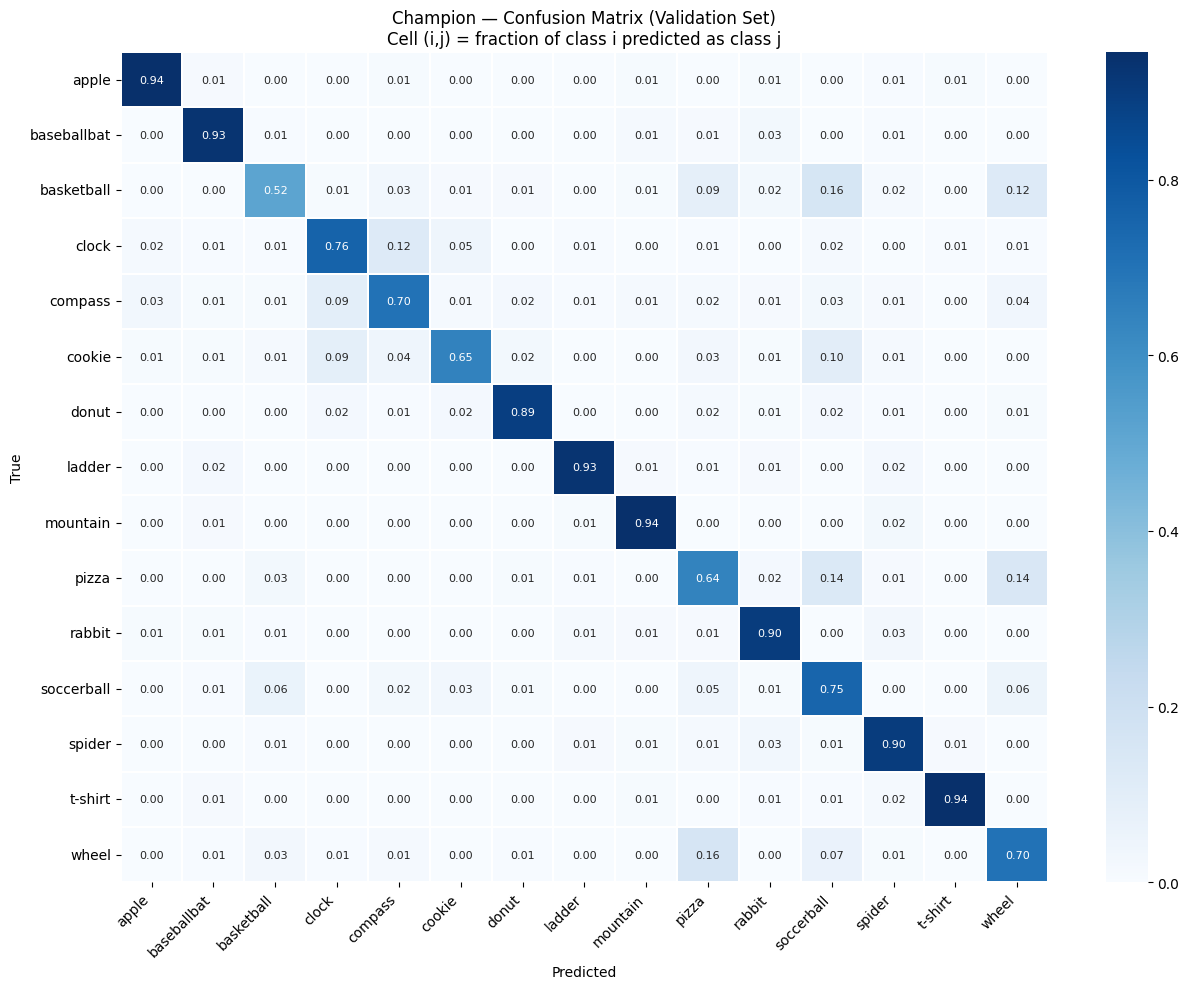

Top-2 Most Confused Pairs:
  wheel          -> pizza         : 64/400 (16.0%)
  basketball     -> soccerball    : 63/400 (15.8%)


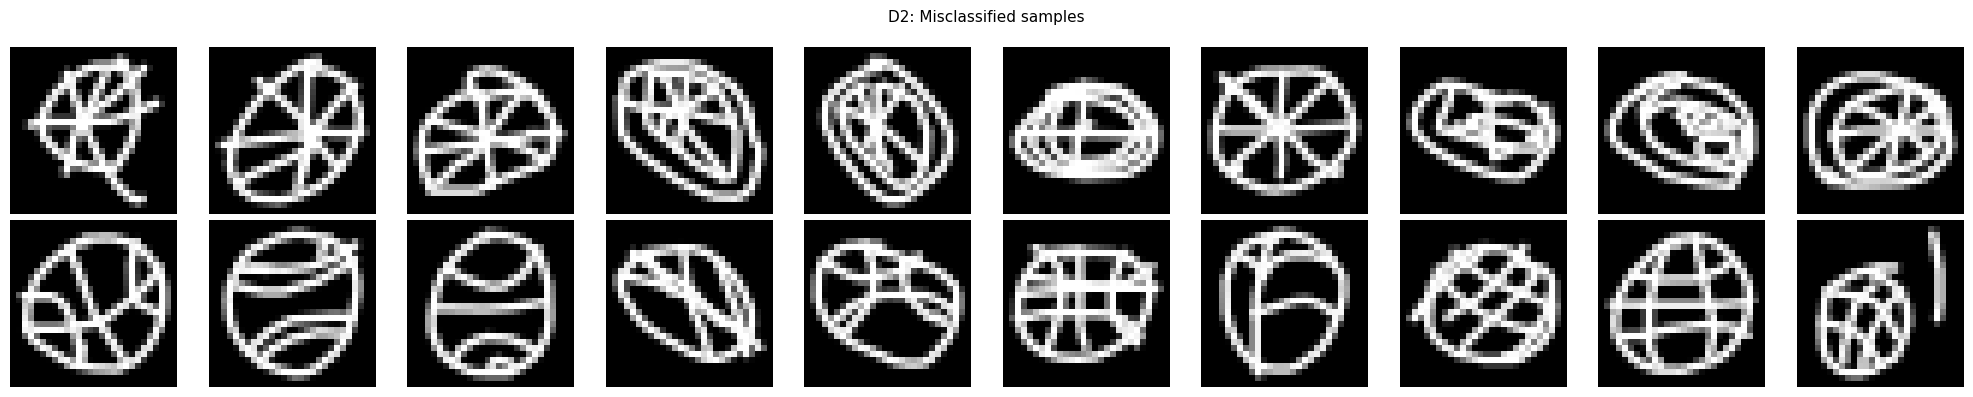

In [29]:
# part D: confusion matrix

val_preds = predict_single(champion, x_val)
cm        = confusion_matrix(y_val.numpy(), val_preds)
cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(13,10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, annot_kws={'size':8}, linewidths=0.3)
ax.set(title='Champion — Confusion Matrix (Validation Set)\n'
             'Cell (i,j) = fraction of class i predicted as class j',
       xlabel='Predicted', ylabel='True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

cm_off = cm_norm.copy()
np.fill_diagonal(cm_off, 0.0)
top_pairs = []
for fi in np.argsort(cm_off.ravel())[::-1]:
    i, j = divmod(fi, NUM_CLASSES)
    top_pairs.append((i,j,cm_off[i,j]))
    if len(top_pairs)==2: break

print('Top-2 Most Confused Pairs:')
for tc, pc, rate in top_pairs:
    print(f'  {class_names[tc]:<14} -> {class_names[pc]:<14}: '
          f'{cm[tc,pc]}/{cm[tc].sum()} ({rate*100:.1f}%)')

if top_pairs:
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    for row, (tc, pc, rate) in enumerate(top_pairs):
        idx_wrong = np.where((y_val.numpy()==tc) & (val_preds==pc))[0][:10]
        for col, idx in enumerate(idx_wrong):
            img = (x_va_np[idx]*px_std + px_mean).reshape(28,28)
            axes[row, col].imshow(img, cmap='gray'); axes[row, col].axis('off')
        for col in range(len(idx_wrong), 10): axes[row, col].axis('off')
        axes[row, 0].set_ylabel(
            f'{class_names[tc]}\n->{class_names[pc]}\n({rate*100:.0f}%)',
            fontsize=8.5, rotation=0, labelpad=90, va='center')
    plt.suptitle('D2: Misclassified samples', fontsize=11)
    plt.tight_layout()
    plt.savefig('confused_samples.png', dpi=150, bbox_inches='tight')
    plt.show()



## Part E : Report + Rationale

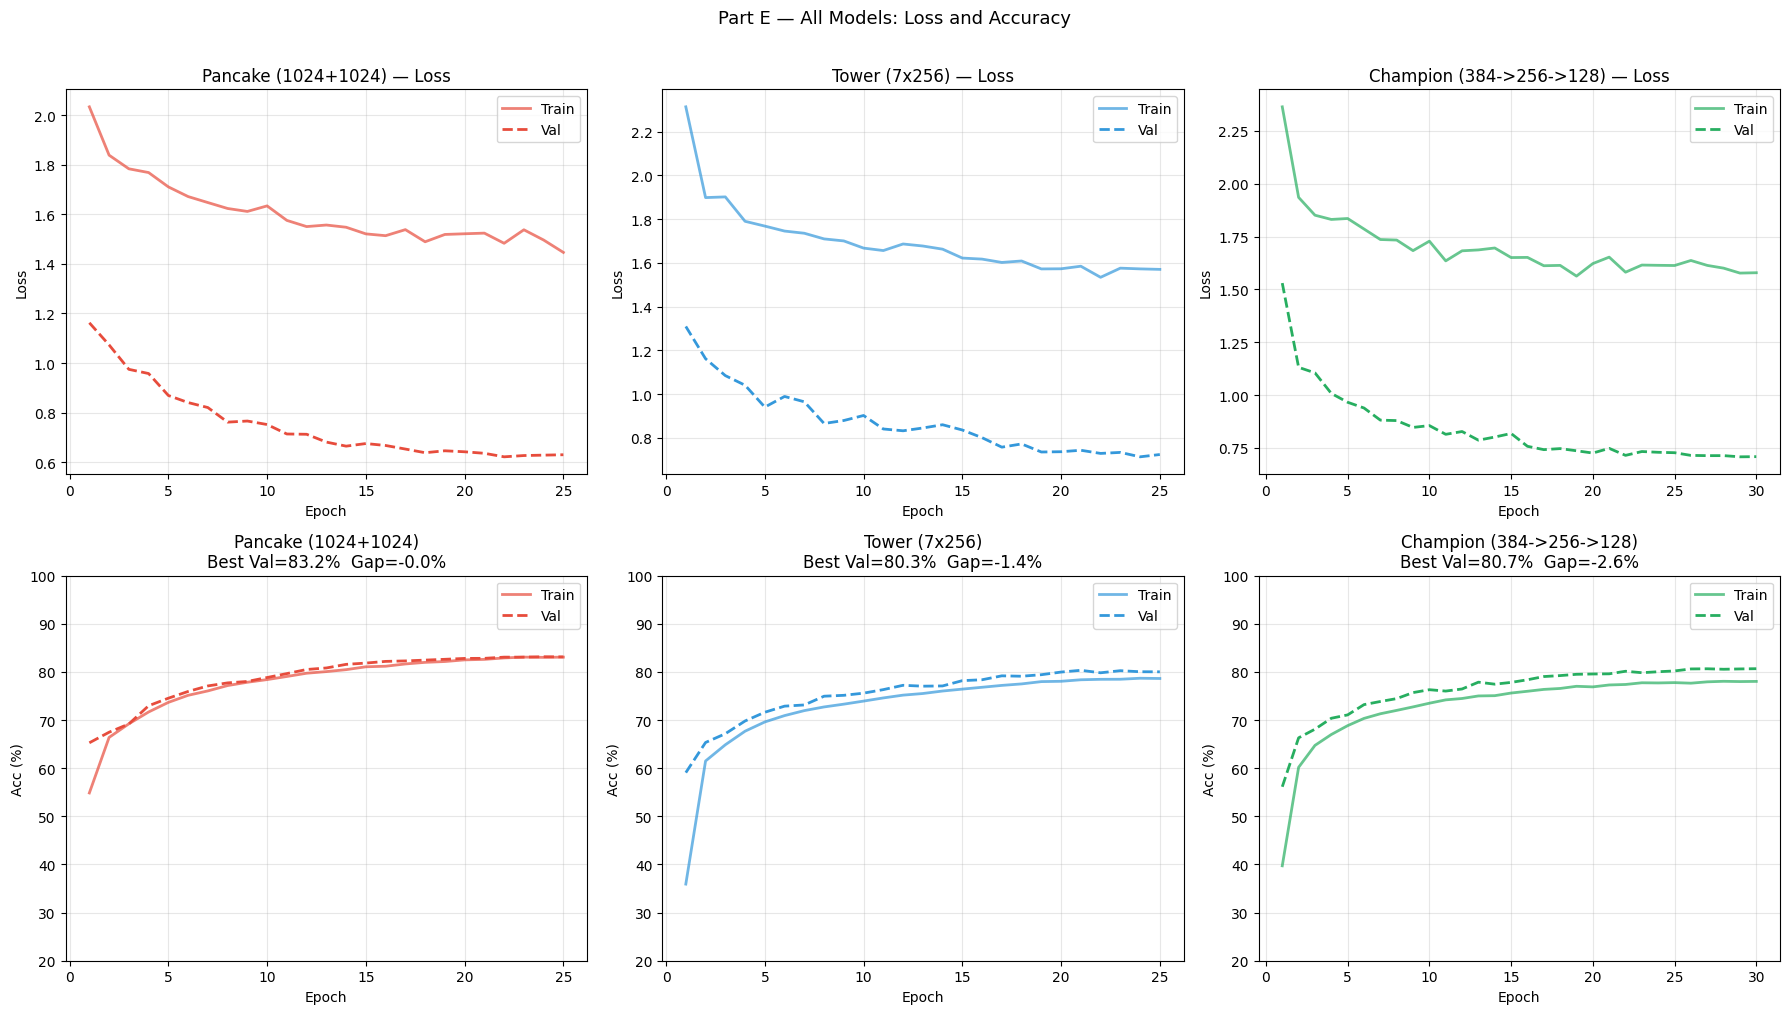

In [30]:
# Curves for all 3 models

fig, axes = plt.subplots(2, 3, figsize=(18,10))
specs = [
    ('Pancake (1024+1024)',       pancake_h, '#e74c3c'),
    ('Tower (7x256)',             tower_h,   '#3498db'),
    ('Champion (384->256->128)', champ_h,   '#27ae60'),
]
for col, (name, hist, color) in enumerate(specs):
    eps  = range(1, len(hist['tl'])+1)
    bv   = max(hist['va'])*100
    gap  = (hist['ta'][-1]-hist['va'][-1])*100

    ax = axes[0,col]
    ax.plot(eps, hist['tl'], color=color, lw=2, alpha=0.7, label='Train')
    ax.plot(eps, hist['vl'], color=color, lw=2, ls='--', label='Val')
    ax.set(title=f'{name} — Loss', xlabel='Epoch', ylabel='Loss')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1,col]
    ax.plot(eps, [a*100 for a in hist['ta']], color=color, lw=2, alpha=0.7, label='Train')
    ax.plot(eps, [a*100 for a in hist['va']], color=color, lw=2, ls='--', label='Val')
    ax.set(title=f'{name}\nBest Val={bv:.1f}%  Gap={gap:+.1f}%',
           xlabel='Epoch', ylabel='Acc (%)', ylim=[20,100])
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Part E — All Models: Loss and Accuracy', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('part_e_all_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# part E: Comparison table

print()
print(f'  {"Model":<10}  {"Architecture":<28}  {"Params":>10}  {"Epochs":>6}  {"Best Val":>9}')
print('  ' + '-'*74)
for name, arch, p, hist, bv in [
    ('Pancake',  '784->1024->1024->15',    pancake_p,  pancake_h, pancake_bv),
    ('Tower',    '784->[256x7]->15',        tower_p,    tower_h,   tower_bv),
    ('Champion', '784->384->256->128->15', champion_p, champ_h,   champ_bv),
]:
    ep  = len(hist['ta'])
    tag = '  ' if name == 'Champion' else ''
    print(f'  {name:<10}  {arch:<28}  {p:>10,}  {ep:>6}  {bv*100:>8.2f}%{tag}')

print()
print(f'{champion_p:,} params  |  {FINAL_EPOCHS} epochs ')


  Model       Architecture                      Params  Epochs   Best Val
  --------------------------------------------------------------------------
  Pancake     784->1024->1024->15            1,872,911      25     83.17%
  Tower       784->[256x7]->15                 603,151      25     80.35%
  Champion    784->384->256->128->15           436,367      30     80.68%  

436,367 params  |  25 epochs 
